# s04 — La matriz W
## CM0866 · Clase 4 · EAFIT 2026

---

Este notebook tiene tres partes que siguen el hilo de la clase:

**Parte 1 — Los residuos del OLS** tienen geografía. El modelo clásico no lo sabe.

**Parte 2 — Tres tipos de W**. Cada una operacionaliza una teoría distinta sobre quién es vecino de quién.

**Parte 3 — El rezago espacial Wy**. La primera herramienta que usa la W para algo útil.

---

Usamos una ciudad sintética de 15×15 manzanas con tres tipos de barrio. La ciudad es imaginaria pero el problema es real.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Librerías e imports
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from shapely.geometry import Polygon, LineString
from libpysal.weights import Queen, KNN, DistanceBand
from libpysal import weights
import warnings
warnings.filterwarnings('ignore')

# Estilo visual limpio para todos los mapas
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

np.random.seed(42)
print('✓ Librerías importadas')

✓ Librerías importadas


---
### La ciudad sintética — una cuadrícula de 15×15 manzanas

Antes de añadir barrios ni precios, construimos la base geométrica:
una grilla de **225 manzanas cuadradas** de 100m × 100m cada una,
referenciada en el sistema UTM zona 18N (EPSG:32618 — el de Medellín).

Cada manzana es un polígono definido por sus 4 vértices.
Juntas forman un área de 1.5km × 1.5km — el tamaño de un barrio real.

| Parámetro | Valor |
|---|---|
| Manzanas por lado | 15 |
| Lado de cada manzana | 100 m |
| Área total | 1.5 km × 1.5 km |
| Sistema de referencia | EPSG:32618 (UTM 18N — Medellín) |
| Total manzanas | 225 |

> *Los ejes del mapa muestran coordenadas en metros — de 0 a 1.500m en X y en Y.
> Cada celda de la grilla es una manzana. En las celdas siguientes
> asignaremos barrios, precios y efectos espaciales sobre esta base.*

Grilla construida: 225 manzanas (15×15)
Extensión: 1500m × 1500m = 1.5km × 1.5km
CRS: EPSG:32618

Primeras 3 manzanas (fila, columna, geometría):
   fila  columna                                           geometry
0     0        0        POLYGON ((0 0, 100 0, 100 100, 0 100, 0 0))
1     0        1  POLYGON ((100 0, 200 0, 200 100, 100 100, 100 0))
2     0        2  POLYGON ((200 0, 300 0, 300 100, 200 100, 200 0))


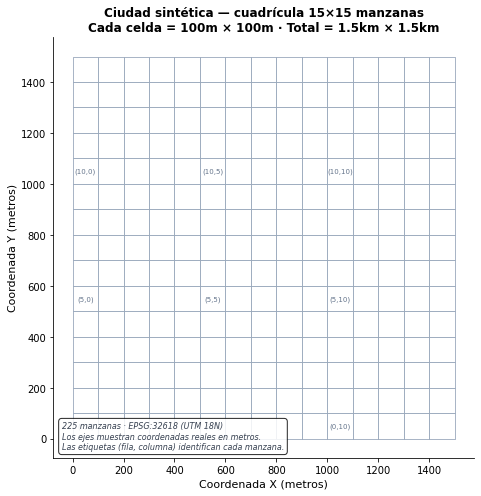


→ Esta grilla vacía es la base geométrica.
→ En la siguiente celda añadiremos los barrios y sus efectos sobre el precio.
→ Los ejes muestran coordenadas UTM en metros — de 0 a 1500m en X y en Y.
→ Cada celda de la grilla corresponde a una manzana de 100m × 100m.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — La cuadrícula base: 15×15 manzanas de 100m × 100m
# Esta es la geometría sobre la que construiremos la ciudad sintética
# ─────────────────────────────────────────────────────────────────────────────

N    = 15    # manzanas por lado
LADO = 100   # metros por manzana

# Construir los polígonos de la grilla
cells, filas, columnas = [], [], []
for r in range(N):
    for c in range(N):
        x0, y0 = c * LADO, r * LADO
        cells.append(Polygon([
            (x0, y0), (x0+LADO, y0),
            (x0+LADO, y0+LADO), (x0, y0+LADO)
        ]))
        filas.append(r)
        columnas.append(c)

grilla = gpd.GeoDataFrame(
    {'fila': filas, 'columna': columnas, 'geometry': cells},
    crs='EPSG:32618'
)

print(f'Grilla construida: {len(grilla)} manzanas ({N}×{N})')
print(f'Extensión: {N*LADO}m × {N*LADO}m = {N*LADO/1000:.1f}km × {N*LADO/1000:.1f}km')
print(f'CRS: {grilla.crs}')
print()
print('Primeras 3 manzanas (fila, columna, geometría):')
print(grilla[['fila','columna','geometry']].head(3).to_string())

# ── Visualizar la grilla vacía ────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

grilla.plot(
    ax=ax,
    facecolor='white',
    edgecolor='#94a3b8',
    linewidth=0.8
)

# Etiquetas de fila y columna cada 5 manzanas
for r in range(0, N, 5):
    for c in range(0, N, 5):
        ax.text(
            c * LADO + LADO/2,
            r * LADO + LADO/2,
            f'({r},{c})',
            ha='center', va='center',
            fontsize=7, color='#64748b'
        )

ax.set_xlabel('Coordenada X (metros)', fontsize=11)
ax.set_ylabel('Coordenada Y (metros)', fontsize=11)
ax.set_title(
    f'Ciudad sintética — cuadrícula {N}×{N} manzanas\n'
    f'Cada celda = 100m × 100m · Total = {N*LADO/1000:.1f}km × {N*LADO/1000:.1f}km',
    fontsize=12, fontweight='bold'
)

# Anotación explicativa
ax.text(
    0.02, 0.02,
    f'225 manzanas · EPSG:32618 (UTM 18N)\n'
    f'Los ejes muestran coordenadas reales en metros.\n'
    f'Las etiquetas (fila, columna) identifican cada manzana.',
    transform=ax.transAxes, fontsize=8,
    color='#374151', style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)

plt.tight_layout()
plt.savefig('outputs/c04_00_grilla_base.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Esta grilla vacía es la base geométrica.')
print('→ En la siguiente celda añadiremos los barrios y sus efectos sobre el precio.')
print('→ Los ejes muestran coordenadas UTM en metros — de 0 a 1500m en X y en Y.')
print('→ Cada celda de la grilla corresponde a una manzana de 100m × 100m.')

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Construir la ciudad sintética
# 15×15 manzanas · 3 tipos de barrio · precio de vivienda como variable
# ─────────────────────────────────────────────────────────────────────────────

N    = 15       # manzanas por lado
LADO = 100      # metros

cells, filas, columnas = [], [], []
for r in range(N):
    for c in range(N):
        x0, y0 = c * LADO, r * LADO
        cells.append(Polygon([
            (x0, y0), (x0+LADO, y0),
            (x0+LADO, y0+LADO), (x0, y0+LADO)
        ]))
        filas.append(r)
        columnas.append(c)

ciudad = gpd.GeoDataFrame(
    {'fila': filas, 'columna': columnas, 'geometry': cells},
    crs='EPSG:32618'
)

# ── Barrios y sus efectos (la "verdad" que el OLS no verá) ───────────────────
ciudad['efecto_barrio'] = 0.0
ciudad['tipo_barrio']   = 'Resto'

mask_p = (ciudad['fila'] >= 10) & (ciudad['columna'] >= 10)
mask_b = (ciudad['fila'].between(6,9)) & (ciudad['columna'].between(5,12))
mask_d = (ciudad['fila'] <= 4) & (ciudad['columna'] <= 4)

ciudad.loc[mask_p, 'efecto_barrio'] =  80;  ciudad.loc[mask_p, 'tipo_barrio'] = 'Premium (+80M)'
ciudad.loc[mask_b, 'efecto_barrio'] =  40;  ciudad.loc[mask_b, 'tipo_barrio'] = 'Buena (+40M)'
ciudad.loc[mask_d, 'efecto_barrio'] = -60;  ciudad.loc[mask_d, 'tipo_barrio'] = 'Deprimida (-60M)'

# ── Variables que el OLS sí verá ─────────────────────────────────────────────
n = len(ciudad)
ciudad['m2']          = 60 + np.random.normal(0, 15, n)
ciudad['habitaciones'] = np.random.choice([1,2,3,4], n, p=[.15,.4,.35,.1]).astype(float)
ciudad['piso']        = np.random.choice(range(1,21), n).astype(float)

# ── Precio real (incluye el efecto barrio) ────────────────────────────────────
ciudad['precio_real'] = (
    200
    + 3.5  * ciudad['m2']
    + 15   * ciudad['habitaciones']
    + 2    * ciudad['piso']
    + ciudad['efecto_barrio']          # ← esto el OLS NO lo verá
    + np.random.normal(0, 20, n)
)

print(f'Ciudad: {len(ciudad)} manzanas en {N}×{N} grilla')
print(f'Precio medio por tipo de barrio:')
print(ciudad.groupby('tipo_barrio')['precio_real'].mean().round(0))

Ciudad: 225 manzanas en 15×15 grilla
Precio medio por tipo de barrio:
tipo_barrio
Buena (+40M)        498.0
Deprimida (-60M)    404.0
Premium (+80M)      564.0
Resto               468.0
Name: precio_real, dtype: float64


---
## Parte 1 — Los residuos del OLS tienen geografía

Ajustamos un modelo OLS que solo ve metros cuadrados, habitaciones y piso.
**No ve los barrios.** Eso tiene consecuencias que se pueden mapear.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — OLS ciego: ajuste y residuos
# ─────────────────────────────────────────────────────────────────────────────

# Matriz de variables que el modelo VE
X = np.column_stack([
    np.ones(n),
    ciudad['m2'].values,
    ciudad['habitaciones'].values,
    ciudad['piso'].values,
    # ← aquí debería ir el efecto_barrio, pero el modelo no lo sabe
])
y = ciudad['precio_real'].values

# Estimación OLS
betas, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
ciudad['precio_pred'] = X @ betas
ciudad['residuo']     = ciudad['precio_real'] - ciudad['precio_pred']

# R² del modelo
ss_res = np.sum(ciudad['residuo']**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot

print('─── Coeficientes OLS ───')
nombres = ['Intercepto (B0)', 'm²', 'habitaciones', 'piso']
reales  = [200, 3.5, 15, 2]
for nombre, b, real in zip(nombres, betas, reales):
    print(f'  {nombre:<20}  estimado: {b:7.2f}   real: {real}')

print(f'\nR² del modelo ciego: {r2:.3f}')
print()
print('─── Residuo medio por barrio ───')
print(ciudad.groupby('tipo_barrio')['residuo'].mean().round(1))
print()
print('¿Ven el patrón? El modelo subestima en zonas premium y sobreestima en zonas deprimidas.')

─── Coeficientes OLS ───
  Intercepto (B0)       estimado:  185.85   real: 200
  m²                    estimado:    3.89   real: 3.5
  habitaciones          estimado:   14.64   real: 15
  piso                  estimado:    2.09   real: 2

R² del modelo ciego: 0.682

─── Residuo medio por barrio ───
tipo_barrio
Buena (+40M)        32.4
Deprimida (-60M)   -58.3
Premium (+80M)      72.7
Resto               -9.8
Name: residuo, dtype: float64

¿Ven el patrón? El modelo subestima en zonas premium y sobreestima en zonas deprimidas.


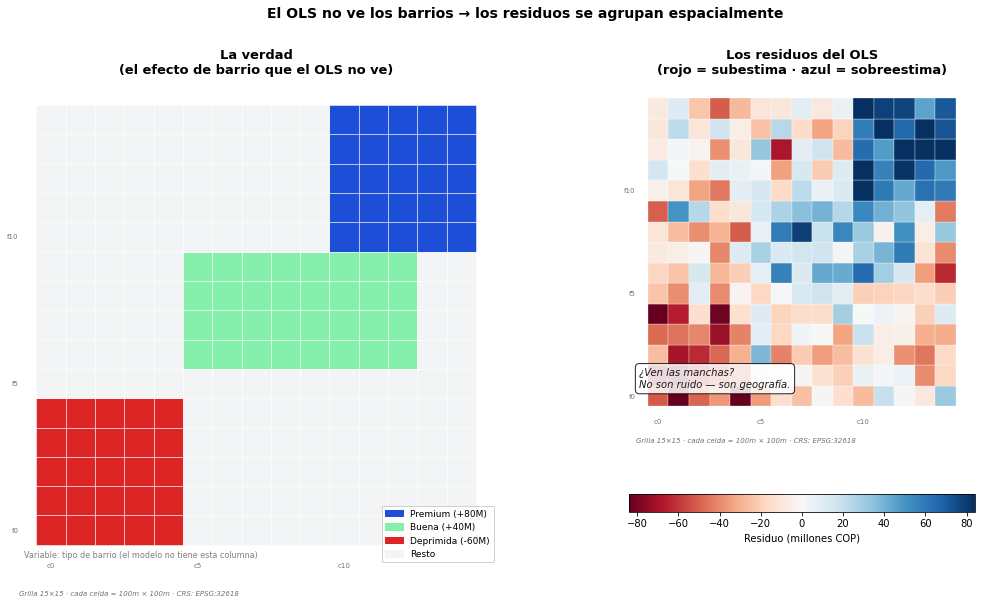


→ Las etiquetas f0, f5, f10 y c0, c5, c10 corresponden a filas y columnas
  del mismo sistema de la grilla base (0 a 14).
→ Comparar los dos paneles: las manchas del derecho reproducen
  exactamente los barrios del izquierdo.
→ El modelo cometió errores sistemáticos en el espacio.
  Eso viola el supuesto de independencia del OLS.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Mapa: la verdad vs. los residuos
# Mismo sistema de referencia que la grilla base: filas 0-14, columnas 0-14
# ─────────────────────────────────────────────────────────────────────────────

colores_barrio = {
    'Premium (+80M)':  '#1d4ed8',
    'Buena (+40M)':    '#86efac',
    'Deprimida (-60M)':'#dc2626',
    'Resto':           '#f3f4f6',
}

def añadir_etiquetas_grilla(ax, N=15, LADO=100, paso=5, fontsize=7):
    """Añade etiquetas de fila y columna en los bordes del mapa."""
    # Etiquetas de columna (eje X) — abajo
    for c in range(0, N, paso):
        ax.text(c * LADO + LADO/2, -LADO * 0.6,
                f'c{c}', ha='center', va='top',
                fontsize=fontsize, color='#64748b')
    # Etiquetas de fila (eje Y) — izquierda
    for r in range(0, N, paso):
        ax.text(-LADO * 0.6, r * LADO + LADO/2,
                f'f{r}', ha='right', va='center',
                fontsize=fontsize, color='#64748b')
    # Nota del sistema de referencia
    ax.text(0.01, -0.06,
            f'Grilla {N}×{N} · cada celda = {LADO}m × {LADO}m · CRS: EPSG:32618',
            transform=ax.transAxes, fontsize=7,
            color='#6b7280', style='italic')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Panel izquierdo: la verdad que el OLS no ve ──────────────────────────────
ax1 = axes[0]
for tipo, color in colores_barrio.items():
    ciudad[ciudad['tipo_barrio'] == tipo].plot(
        ax=ax1, color=color, edgecolor='white', linewidth=0.5
    )
patches = [mpatches.Patch(color=c, label=t) for t, c in colores_barrio.items()]
ax1.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.9)
ax1.set_title('La verdad\n(el efecto de barrio que el OLS no ve)',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_axis_off()
ax1.text(0.02, 0.02, 'Variable: tipo de barrio (el modelo no tiene esta columna)',
         transform=ax1.transAxes, fontsize=8, color='gray')
añadir_etiquetas_grilla(ax1)

# ── Panel derecho: los residuos ───────────────────────────────────────────────
ax2 = axes[1]
vlim = ciudad['residuo'].abs().quantile(0.95)
ciudad.plot(
    column='residuo', cmap='RdBu', ax=ax2,
    vmin=-vlim, vmax=vlim,
    edgecolor='white', linewidth=0.3,
    legend=True,
    legend_kwds={'label': 'Residuo (millones COP)',
                 'shrink': 0.6, 'orientation': 'horizontal'}
)
ax2.set_title('Los residuos del OLS\n(rojo = subestima · azul = sobreestima)',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_axis_off()
ax2.text(0.02, 0.10,
         '¿Ven las manchas?\nNo son ruido — son geografía.',
         transform=ax2.transAxes, fontsize=10, style='italic', color='#1a1a1a',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
añadir_etiquetas_grilla(ax2)

plt.suptitle(
    'El OLS no ve los barrios → los residuos se agrupan espacialmente',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_01_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Las etiquetas f0, f5, f10 y c0, c5, c10 corresponden a filas y columnas')
print('  del mismo sistema de la grilla base (0 a 14).')
print('→ Comparar los dos paneles: las manchas del derecho reproducen')
print('  exactamente los barrios del izquierdo.')
print('→ El modelo cometió errores sistemáticos en el espacio.')
print('  Eso viola el supuesto de independencia del OLS.')

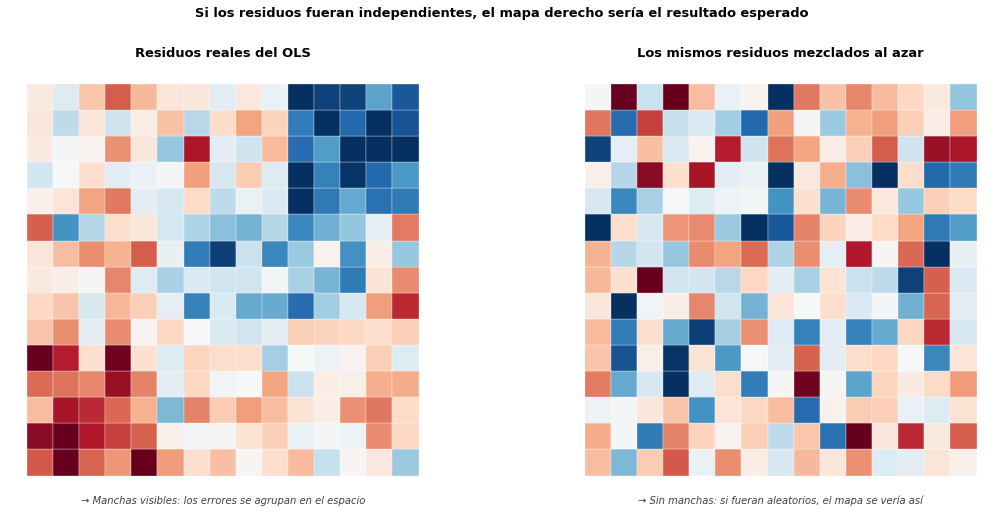


→ La pregunta que el índice de Moran I responderá en la Clase 5:
   ¿El mapa izquierdo podría haberse producido por azar? ¿Cuán probable es ese mapa si la distribución fuera aleatoria?


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — ¿Los residuos aleatorios se verían así?
# Comparación: residuos reales vs. residuos mezclados al azar
# ─────────────────────────────────────────────────────────────────────────────

# Mezclar los residuos al azar — quitar la geografía
residuos_random = ciudad['residuo'].values.copy()
np.random.shuffle(residuos_random)
ciudad['residuo_random'] = residuos_random

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, titulo, subtitulo in [
    (axes[0], 'residuo',
     'Residuos reales del OLS',
     '→ Manchas visibles: los errores se agrupan en el espacio'),
    (axes[1], 'residuo_random',
     'Los mismos residuos mezclados al azar',
     '→ Sin manchas: si fueran aleatorios, el mapa se vería así'),
]:
    ciudad.plot(
        column=col, cmap='RdBu', ax=ax,
        vmin=-vlim, vmax=vlim,
        edgecolor='white', linewidth=0.3, legend=False
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=8)
    ax.set_axis_off()
    ax.text(0.5, -0.02, subtitulo,
            transform=ax.transAxes, fontsize=10, style='italic',
            ha='center', color='#374151')

plt.suptitle(
    'Si los residuos fueran independientes, el mapa derecho sería el resultado esperado',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_02_residuos_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ La pregunta que el índice de Moran I responderá en la Clase 5:')
print('   ¿El mapa izquierdo podría haberse producido por azar? ¿Cuán probable es ese mapa si la distribución fuera aleatoria?')

---
### ¿Cómo se ve el problema de barrio en el gráfico de regresión?

El mapa de residuos muestra *dónde* se agrupan los errores.
Pero el gráfico clásico de diagnóstico OLS — **residuos vs. valores predichos** —
es el que cualquier software de regresión produce automáticamente.

El problema: ese gráfico **no tiene información espacial**.
Un econometrista que solo lo vea podría concluir que el modelo está bien.

La solución: **colorear los puntos por barrio**.
Si el OLS funciona correctamente para todos los barrios,
los colores deben mezclarse aleatoriamente alrededor de cero.
Si hay efecto de barrio no modelado, los colores se separan en bandas.

> *Tres paneles — la misma historia vista desde la regresión lineal.*

─── Residuo medio por barrio ───────────────────────────────────────
  Premium (+80M)        : +72.7 MM COP
  Buena (+40M)          : +32.4 MM COP
  Resto                 : -9.8 MM COP
  Deprimida (-60M)      : -58.3 MM COP

→ Panel superior izquierdo: la ecuación de regresión visible.
  Puntos sobre la diagonal 45° → el modelo subestima (εᵢ > 0).
  Puntos bajo la diagonal 45° → el modelo sobreestima (εᵢ < 0).

→ Panel superior derecho: residuos vs. fitted values — el gráfico
  estándar de diagnóstico. La línea en cero no es la recta de regresión
  — es la referencia del error nulo (εᵢ = 0).

→ Paneles inferiores: el color revela lo que el gráfico clásico ocultaba.


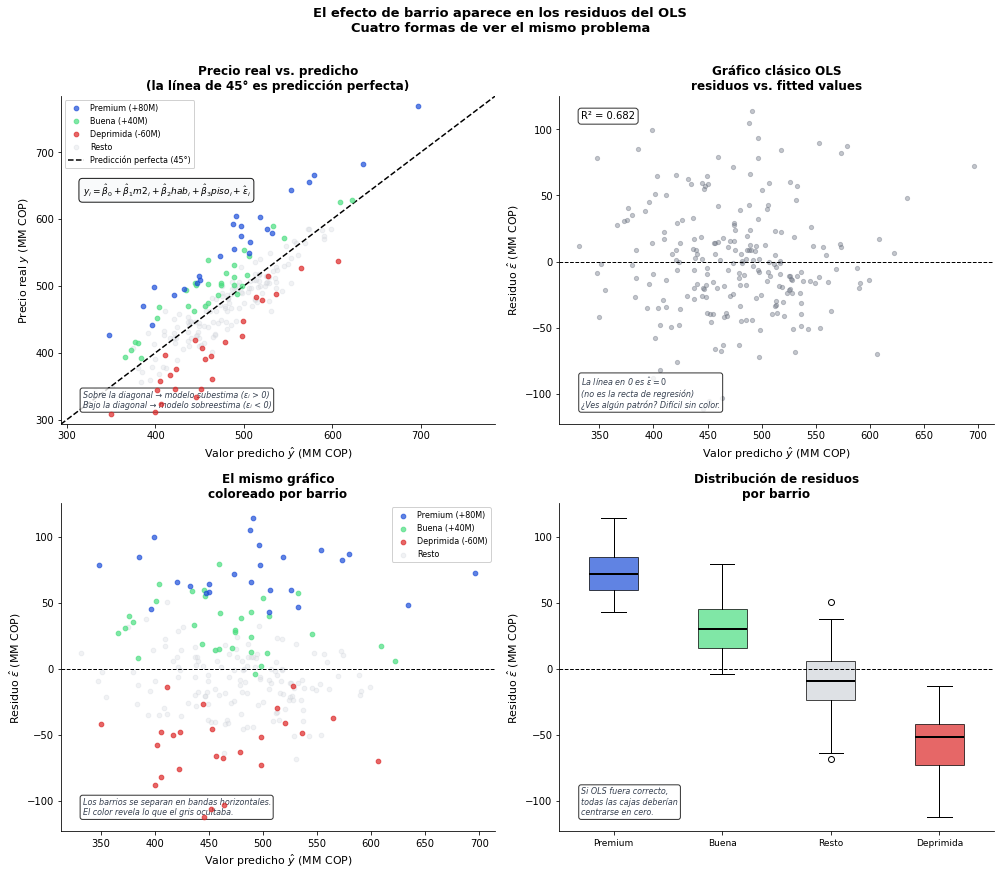

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — El efecto de barrio visto desde la regresión lineal
# Cuatro paneles: y vs ŷ · gráfico clásico · coloreado · boxplot
# ─────────────────────────────────────────────────────────────────────────────

colores_barrio = {
    'Premium (+80M)':   '#1d4ed8',
    'Buena (+40M)':     '#4ade80',
    'Deprimida (-60M)': '#dc2626',
    'Resto':            '#d1d5db',
}
zorder_barrio = {'Premium (+80M)': 4, 'Buena (+40M)': 3,
                 'Deprimida (-60M)': 4, 'Resto': 1}

y_real       = ciudad['precio_real'].values
y_pred_arr   = ciudad['precio_pred'].values
residuos_arr = ciudad['residuo'].values
barrio_arr   = ciudad['tipo_barrio'].values

r2_val = 1 - np.sum(residuos_arr**2) / np.sum((y_real - y_real.mean())**2)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax0, ax1 = axes[0, 0], axes[0, 1]
ax2, ax3 = axes[1, 0], axes[1, 1]

# ── Panel 0: y_real vs. y_pred — la línea de 45° ────────────────────────────
lim_min = min(y_real.min(), y_pred_arr.min()) - 15
lim_max = max(y_real.max(), y_pred_arr.max()) + 15

for nombre, color in colores_barrio.items():
    mask = barrio_arr == nombre
    ax0.scatter(y_pred_arr[mask], y_real[mask],
                alpha=0.7 if nombre != 'Resto' else 0.3,
                s=22, color=color, label=nombre,
                zorder=zorder_barrio[nombre])

ax0.plot([lim_min, lim_max], [lim_min, lim_max],
         color='black', linewidth=1.5, linestyle='--',
         label='Predicción perfecta (45°)')
ax0.set_xlim(lim_min, lim_max)
ax0.set_ylim(lim_min, lim_max)
ax0.set_xlabel('Valor predicho $\\hat{y}$ (MM COP)', fontsize=11)
ax0.set_ylabel('Precio real $y$ (MM COP)', fontsize=11)
ax0.set_title('Precio real vs. predicho\n(la línea de 45° es predicción perfecta)',
              fontsize=12, fontweight='bold')
ax0.legend(fontsize=8, framealpha=0.9, loc='upper left')
ax0.text(0.05, 0.70,
         '$y_i = \\hat{\\beta}_0 + \\hat{\\beta}_1 m2_i'
         ' + \\hat{\\beta}_2 hab_i + \\hat{\\beta}_3 piso_i + \\hat{\\varepsilon}_i$',
         transform=ax0.transAxes, fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9fafb', alpha=0.9))
ax0.text(0.05, 0.05,
         'Sobre la diagonal → modelo subestima (εᵢ > 0)\nBajo la diagonal → modelo sobreestima (εᵢ < 0)',
         transform=ax0.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Panel 1: residuos vs. fitted values SIN color ───────────────────────────
ax1.scatter(y_pred_arr, residuos_arr, alpha=0.4, s=18, color='#6b7280')
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.set_xlabel('Valor predicho $\\hat{y}$ (MM COP)', fontsize=11)
ax1.set_ylabel('Residuo $\\hat{\\varepsilon}$ (MM COP)', fontsize=11)
ax1.set_title('Gráfico clásico OLS\nresiduos vs. fitted values',
              fontsize=12, fontweight='bold')
ax1.text(0.05, 0.93, f'R² = {r2_val:.3f}', transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax1.text(0.05, 0.05,
         'La línea en 0 es $\\hat{\\varepsilon} = 0$\n(no es la recta de regresión)\n¿Ves algún patrón? Difícil sin color.',
         transform=ax1.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Panel 2: residuos vs. fitted values CON color de barrio ─────────────────
for nombre, color in colores_barrio.items():
    mask = barrio_arr == nombre
    ax2.scatter(y_pred_arr[mask], residuos_arr[mask],
                alpha=0.7 if nombre != 'Resto' else 0.3,
                s=22, color=color, label=nombre,
                zorder=zorder_barrio[nombre])
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('Valor predicho $\\hat{y}$ (MM COP)', fontsize=11)
ax2.set_ylabel('Residuo $\\hat{\\varepsilon}$ (MM COP)', fontsize=11)
ax2.set_title('El mismo gráfico\ncoloreado por barrio',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right', framealpha=0.9)
ax2.text(0.05, 0.05,
         'Los barrios se separan en bandas horizontales.\nEl color revela lo que el gris ocultaba.',
         transform=ax2.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Panel 3: boxplot de residuos por barrio ───────────────────────────────────
orden       = ['Premium (+80M)', 'Buena (+40M)', 'Resto', 'Deprimida (-60M)']
datos_box   = [residuos_arr[barrio_arr == b] for b in orden]
colores_box = [colores_barrio[b] for b in orden]

bp = ax3.boxplot(datos_box, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.axhline(0, color='black', linewidth=1, linestyle='--')
ax3.set_xticks(range(1, 5))
ax3.set_xticklabels([b.split(' ')[0] for b in orden], fontsize=9)
ax3.set_ylabel('Residuo $\\hat{\\varepsilon}$ (MM COP)', fontsize=11)
ax3.set_title('Distribución de residuos\npor barrio',
              fontsize=12, fontweight='bold')
ax3.text(0.05, 0.05,
         'Si OLS fuera correcto,\ntodas las cajas deberían\ncentrarse en cero.',
         transform=ax3.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

print('─── Residuo medio por barrio ───────────────────────────────────────')
for b in orden:
    media = residuos_arr[barrio_arr == b].mean()
    print(f'  {b:<22}: {media:+.1f} MM COP')
print()
print('→ Panel superior izquierdo: la ecuación de regresión visible.')
print('  Puntos sobre la diagonal 45° → el modelo subestima (εᵢ > 0).')
print('  Puntos bajo la diagonal 45° → el modelo sobreestima (εᵢ < 0).')
print()
print('→ Panel superior derecho: residuos vs. fitted values — el gráfico')
print('  estándar de diagnóstico. La línea en cero no es la recta de regresión')
print('  — es la referencia del error nulo (εᵢ = 0).')
print()
print('→ Paneles inferiores: el color revela lo que el gráfico clásico ocultaba.')

plt.suptitle(
    'El efecto de barrio aparece en los residuos del OLS\n'
    'Cuatro formas de ver el mismo problema',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_04b_residuos_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte 2 — Tres tipos de W

Para corregir el problema necesitamos formalizar quién influye sobre quién. Eso es la W.

Construimos las tres W y comparamos visualmente qué tipo de vecindad define cada una.

```
W es simplemente una tabla que dice:
  wᵢⱼ = 1   si i y j son vecinos
  wᵢⱼ = 0   si no
  wᵢᵢ = 0   siempre (nadie es vecino de sí mismo)
```

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Construir las tres W
# ─────────────────────────────────────────────────────────────────────────────

from libpysal.weights import Queen, KNN, DistanceBand

# W 1 — Contigüidad Queen
w_queen = Queen.from_dataframe(ciudad)
w_queen.transform = 'r'   # row-standardize: los pesos de cada fila suman 1

# W 2 — K vecinos más cercanos (k=5)
w_knn = KNN.from_dataframe(ciudad, k=5)
w_knn.transform = 'r'

# W 3 — Distancia umbral (150 m = 1.5 manzanas)
w_dist = DistanceBand.from_dataframe(ciudad, threshold=150)
w_dist.transform = 'r'

print('─── Cardinalidad de cada W ───')
print(f'Queen  — vecinos promedio: {w_queen.mean_neighbors:.1f}  '
      f'(min: {min(w_queen.cardinalities.values())}  '
      f'max: {max(w_queen.cardinalities.values())})')
print(f'KNN    — vecinos promedio: {w_knn.mean_neighbors:.1f}  '
      f'(siempre exactamente k=5)')
print(f'Dist   — vecinos promedio: {w_dist.mean_neighbors:.1f}  '
      f'(zonas aisladas: {sum(1 for v in w_dist.cardinalities.values() if v==0)})')
print()
print('→ Queen: la cardinalidad varía (esquinas tienen menos vecinos que el centro)')
print('→ KNN:   todos tienen exactamente 5 vecinos, sin importar su posición')
print('→ Dist:  todos dentro de 150m — puede dejar zonas sin vecinos en bordes')

─── Cardinalidad de cada W ───
Queen  — vecinos promedio: 7.2  (min: 3  max: 8)
KNN    — vecinos promedio: 5.0  (siempre exactamente k=5)
Dist   — vecinos promedio: 7.2  (zonas aisladas: 0)

→ Queen: la cardinalidad varía (esquinas tienen menos vecinos que el centro)
→ KNN:   todos tienen exactamente 5 vecinos, sin importar su posición
→ Dist:  todos dentro de 150m — puede dejar zonas sin vecinos en bordes


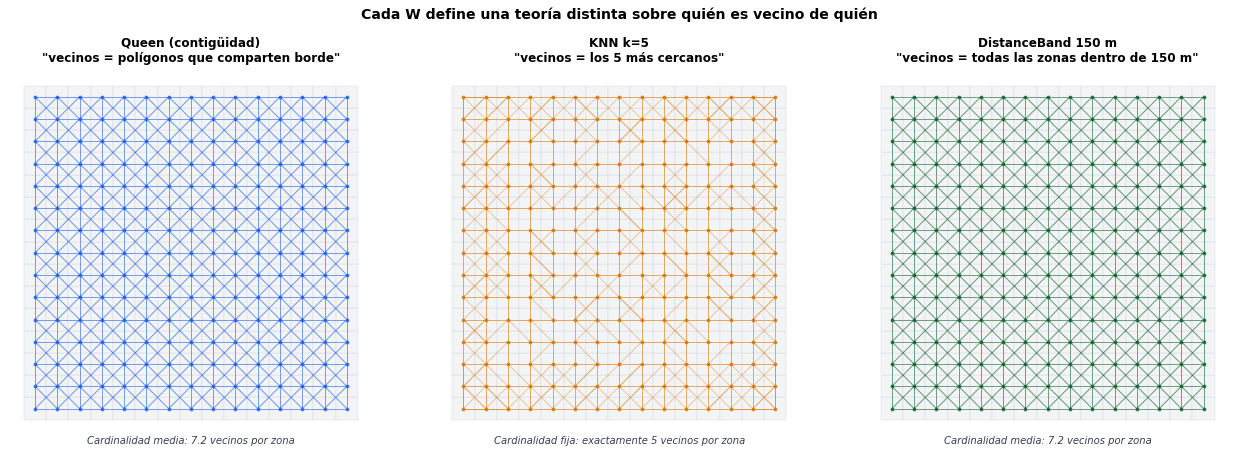


→ Observar: la densidad de líneas varía entre tipos de W
→ Queen: las esquinas tienen pocas conexiones, el centro tiene muchas
→ KNN: todas las zonas tienen exactamente el mismo número de líneas


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Mapa de conectividad: las tres W visualizadas
# Cada línea = una relación de vecindad
# ─────────────────────────────────────────────────────────────────────────────

def dibujar_conexiones(ax, gdf, w, color='#2563EB', alpha=0.35, lw=0.8):
    """Dibuja líneas entre centroides de zonas vecinas."""
    centroids = gdf.geometry.centroid
    for i, vecinos in w.neighbors.items():
        xi, yi = centroids.iloc[i].x, centroids.iloc[i].y
        for j in vecinos:
            xj, yj = centroids.iloc[j].x, centroids.iloc[j].y
            ax.plot([xi, xj], [yi, yj], color=color,
                    alpha=alpha, linewidth=lw, zorder=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

configs = [
    (w_queen, 'Queen (contigüidad)\n"vecinos = polígonos que comparten borde"',
     f'Cardinalidad media: {w_queen.mean_neighbors:.1f} vecinos por zona', '#2563EB'),
    (w_knn,   'KNN k=5\n"vecinos = los 5 más cercanos"',
     'Cardinalidad fija: exactamente 5 vecinos por zona', '#D97706'),
    (w_dist,  'DistanceBand 150 m\n"vecinos = todas las zonas dentro de 150 m"',
     f'Cardinalidad media: {w_dist.mean_neighbors:.1f} vecinos por zona', '#166534'),
]

for ax, (w, titulo, subtitulo, color) in zip(axes, configs):
    # Fondo de manzanas
    ciudad.plot(ax=ax, color='#F3F4F6', edgecolor='#D1D5DB', linewidth=0.4)
    # Líneas de conexión
    dibujar_conexiones(ax, ciudad, w, color=color, alpha=0.4, lw=0.9)
    # Centroides
    ciudad.geometry.centroid.plot(ax=ax, color=color, markersize=8,
                                   alpha=0.8, zorder=3)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=8)
    ax.set_axis_off()
    ax.text(0.5, -0.02, subtitulo,
            transform=ax.transAxes, fontsize=10, ha='center',
            color='#374151', style='italic')

plt.suptitle(
    'Cada W define una teoría distinta sobre quién es vecino de quién',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/c04_03_tipos_W.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Observar: la densidad de líneas varía entre tipos de W')
print('→ Queen: las esquinas tienen pocas conexiones, el centro tiene muchas')
print('→ KNN: todas las zonas tienen exactamente el mismo número de líneas')

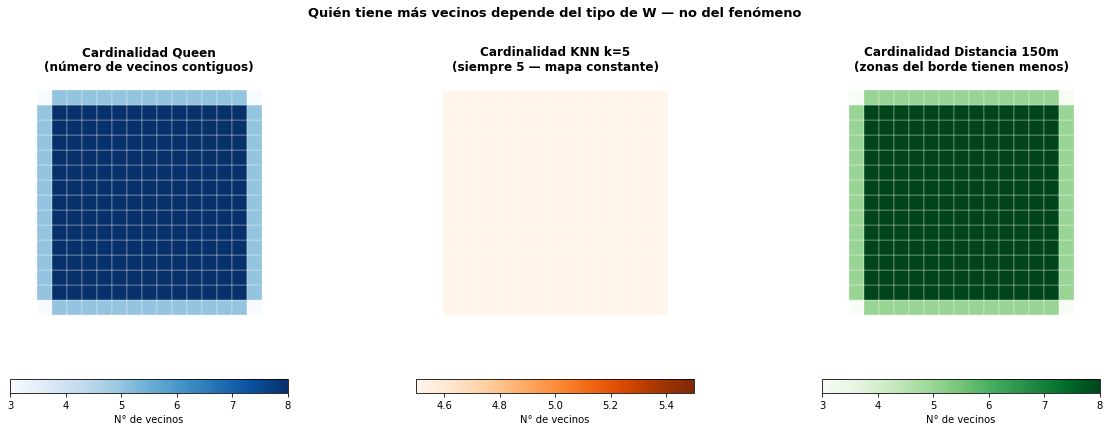


→ Queen: las esquinas tienen 3 vecinos, el centro tiene 8
→ KNN: el mapa es constante — todos tienen exactamente 5
→ Distancia: las zonas del borde tienen menos vecinos dentro del radio


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — Mapa de cardinalidad: ¿quién tiene más vecinos?
# ─────────────────────────────────────────────────────────────────────────────

# Añadir cardinalidad de cada W a la geodataframe
ciudad['card_queen'] = [w_queen.cardinalities[i] for i in range(len(ciudad))]
ciudad['card_knn']   = [w_knn.cardinalities[i]   for i in range(len(ciudad))]
ciudad['card_dist']  = [w_dist.cardinalities[i]  for i in range(len(ciudad))]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, titulo, cmap in [
    (axes[0], 'card_queen', 'Cardinalidad Queen\n(número de vecinos contiguos)', 'Blues'),
    (axes[1], 'card_knn',   'Cardinalidad KNN k=5\n(siempre 5 — mapa constante)', 'Oranges'),
    (axes[2], 'card_dist',  'Cardinalidad Distancia 150m\n(zonas del borde tienen menos)', 'Greens'),
]:
    ciudad.plot(
        column=col, cmap=cmap, ax=ax,
        edgecolor='white', linewidth=0.3,
        legend=True,
        legend_kwds={'label': 'N° de vecinos', 'shrink': 0.6,
                     'orientation': 'horizontal'}
    )
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=8)
    ax.set_axis_off()

plt.suptitle(
    'Quién tiene más vecinos depende del tipo de W — no del fenómeno',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_04_cardinalidad_W.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Queen: las esquinas tienen 3 vecinos, el centro tiene 8')
print('→ KNN: el mapa es constante — todos tienen exactamente 5')
print('→ Distancia: las zonas del borde tienen menos vecinos dentro del radio')

---
## Cierre de la Clase 4

Ya tienen las dos piezas fundamentales:

- **El problema:** los residuos del OLS tienen geografía — los errores no son independientes.
- **La herramienta:** la W formaliza quién influye sobre quién.

Falta la tercera pieza: **el rezago Wy** — cómo usar la W para calcular el contexto espacial de cada zona. 
Eso es la tarea de lectura antes de la Clase 5.

---

### Tarea — Antes de la Clase 5

1. **Ejecutar** el notebook `s05_clase5.ipynb` — celdas de Wy (lectura autónoma)
2. **Verificar** que el GeoPackage del Hito 1 carga correctamente en Python
3. **Completar** la frase de vecindad del equipo:
> *"En nuestro proyecto, dos unidades espaciales son vecinas si ________, porque el fenómeno opera a través de ________"*
4. **Reflexión de bitácora:**
> *¿El patrón que vieron en el mapa de su variable dependiente creen que es real, o podría ser pura casualidad?*

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*